In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import griddata
import matplotlib.patheffects as pe
import os


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.227996,-0.449990,1.123684,118.032741,47.992205,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.231212,-0.339872,1.022306,108.004573,52.019741,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.393163,-0.229470,0.765331,109.827647,54.305771,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,1.274357,-0.293598,0.871468,111.650721,56.591801,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,1.302035,-0.457566,0.945071,115.925719,57.471319,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,1.184753,-0.030921,0.903800,57.890310,10.534469,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,0.948719,-0.199901,1.216728,61.813856,10.733594,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,0.877251,-0.200469,1.267517,65.737402,10.932719,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,0.867521,-0.100735,1.276832,69.660948,11.131844,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [4]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_ameda


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,large1,split,split2,merge,merge2,shapes2,interaction,interaction2,area,deta
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.00001,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46653.514371,-0.000011
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4313.383226,-0.000164
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4336.799061,-0.00007
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6480.379311,-0.000047
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.00002,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6101.676103,-0.000401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1147.953129,0.000186
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8038.013328,0.000109
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9866.414298,0.000095
104568,3519,10649,CE,154.37742,-28.417662,100,257,264.105244,1270.945276,-0.00001,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5581.424065,0.000003


In [5]:
def day_plot(day, df_eddies, df_ameda, out_core_flag=False, center_flag=False):

    fnumber = 1461 + ((day - 1462) // 30)*30
    fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{fnumber:05}.nc'
    with nc.Dataset(fname) as ds:
        ocean_time = ds['ocean_time'][:] / 86400
        t = np.where(ocean_time == day)[0][0]
        ut = ds['u_eastward'][t, -1, :, :].T
        vt = ds['v_northward'][t, -1, :, :].T

    df_day = df_eddies.loc[df_eddies.Day.eq(day)].copy()
    df_day_ameda = df_ameda.loc[df_ameda.Day.eq(day)].copy()
    
    cs = np.hypot(ut, vt)

    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.pcolor(X_grid, Y_grid, cs, shading='nearest', vmin=0, vmax=2.5, cmap='Blues_r')
    fig.colorbar(im, ax=ax, label=r'Current speed (ms$^{-1}$)')

    clrs = np.where(df_day.Cyc.eq('CE'), 'c', 'r')
    ax.scatter(df_day.xc, df_day.yc, c=clrs, edgecolors='k', linewidths=0.8, s=60, zorder=10)

    clrs_ameda = np.where(df_day_ameda.Cyc.eq('CE'), 'c', 'r')
    ax.scatter(df_day_ameda.xc, df_day_ameda.yc, marker='x', c=clrs_ameda, edgecolors='k', linewidths=0.8, s=100, zorder=10)

    for e, xc, yc in zip(df_day_ameda.Eddy, df_day_ameda.xc, df_day_ameda.yc):
        ax.annotate(
            str(e), (xc, yc),
            textcoords='offset points', xytext=(3, -8),
            fontsize=12, color='orange', weight='bold',
            path_effects=[pe.withStroke(linewidth=2, foreground='k')],
            zorder=11
        )

    if center_flag: 
    
        if 'Q' not in df_day.columns:
            df_day['Q'] = list(
                np.stack([
                    np.stack([df_day.q11.values, df_day.q12.values], axis=1),
                    np.stack([df_day.q12.values, df_day.q22.values], axis=1)
                ], axis=1)
            )
    
        for xc, yc, e, Q, Rc, R, cyc in zip(df_day.xc, df_day.yc, df_day.Eddy, df_day.Q, df_day.Rc, df_day.R, df_day.Cyc):
    
            # ----- Where I plot the eddy's maximum tangenital velocity contour -----
            dx_ell, dy_ell = X_grid - xc, Y_grid - yc
            rho2_ell = Q[0,0]*dx_ell**2 + 2*Q[1,0]*dx_ell*dy_ell + Q[1,1]*dy_ell**2 # rho^2
            ax.contour(X_grid, Y_grid, rho2_ell, levels=[Rc**2/2], colors='r' if cyc=='AE' else 'c')
            if out_core_flag:
                ax.contour(X_grid, Y_grid, rho2_ell, levels=[(1.75*R)**2], linestyles='--', colors='r' if cyc=='AE' else 'c')
            # -----------------------------------------------------------------------
    
            ax.annotate(
                str(e), (xc, yc),
                textcoords='offset points', xytext=(3, 3),
                fontsize=12, color='w', weight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='k')],
                zorder=11
            )

    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
                
    ax.set_title(f'Day {day} | {pd.Timestamp("1990-01-01") + pd.Timedelta(days=day)}')
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_xlim(x_grid.min(), x_grid.max())
    ax.set_ylim(y_grid.min(), y_grid.max())
    

/scratch/pbs.8112103.kman.restech.unsw.edu.au/ipykernel_1964231/52767441.py:24: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df_day_ameda.xc, df_day_ameda.yc, marker='x', c=clrs_ameda, edgecolors='k', linewidths=0.8, s=100, zorder=10)
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


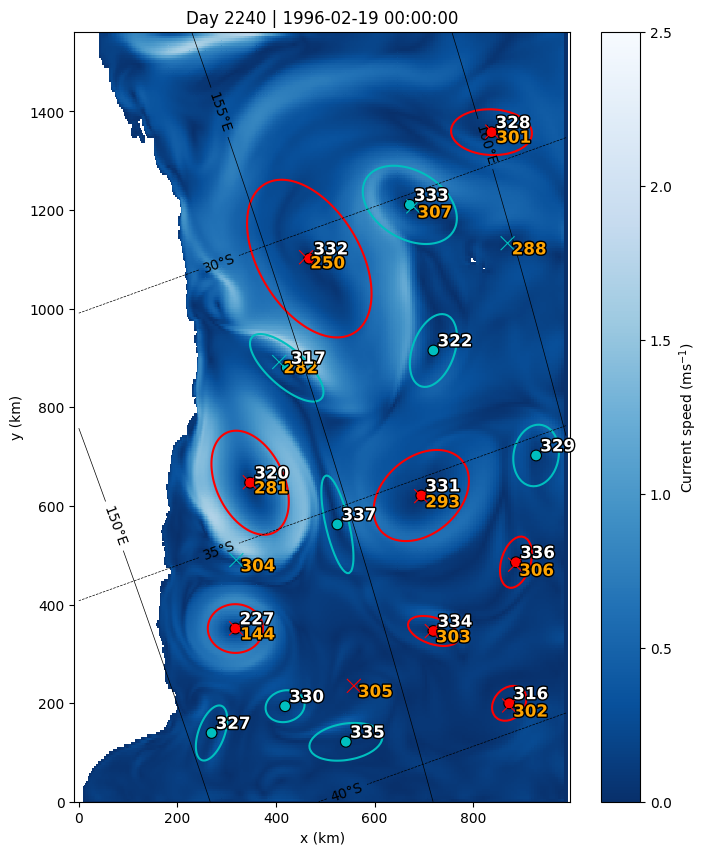

In [6]:
day_plot(2240, df_eddies, df_ameda, center_flag=True, out_core_flag=False)
         

In [7]:
def file_save_plots(
    fname, df_eddies, df_ameda,
    out_core_flag=False,
    center_flag=False,
    dpi=120,
    annotate_ameda=True,
    annotate_centers=True,
    out_dir='/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/daily_snapshots'
):

    os.makedirs(out_dir, exist_ok=True)

    with nc.Dataset(fname) as ds:

        ocean_time = ds['ocean_time'][:] / 86400
        available_days = ocean_time.astype(int)

        df_file = df_eddies.loc[df_eddies.Day.isin(available_days)].copy()
        df_file_ameda = df_ameda.loc[df_ameda.Day.isin(available_days)].copy()

        days = np.union1d(df_file.Day.unique(), df_file_ameda.Day.unique())

        if len(days) == 0:
            return

        for day in np.sort(days):

            t = np.where(ocean_time.astype(int) == int(day))[0][0]

            ut = ds['u_eastward'][t, -1, :, :].T
            vt = ds['v_northward'][t, -1, :, :].T
            cs = np.hypot(ut, vt)

            df_day = df_file.loc[df_file.Day.eq(day)].copy()
            df_day_ameda = df_file_ameda.loc[df_file_ameda.Day.eq(day)].copy()

            fig, ax = plt.subplots(figsize=(8, 10))

            im = ax.pcolormesh(
                X_grid, Y_grid, cs,
                shading='auto',
                vmin=0, vmax=2.5,
                cmap='Blues_r',
                rasterized=True
            )
            fig.colorbar(im, ax=ax, label=r'Current speed (ms$^{-1}$)')

            if len(df_day):
                clrs = np.where(df_day.Cyc.eq('CE'), 'c', 'r')
                ax.scatter(
                    df_day.xc, df_day.yc,
                    c=clrs,
                    edgecolors='k',
                    linewidths=0.5,
                    s=35,
                    zorder=10
                )

            if len(df_day_ameda):
                clrs_ameda = np.where(df_day_ameda.Cyc.eq('CE'), 'c', 'r')
                ax.scatter(
                    df_day_ameda.xc, df_day_ameda.yc,
                    marker='x',
                    c=clrs_ameda,
                    linewidths=1.2,
                    s=90,
                    zorder=12
                )

                if annotate_ameda:
                    for e, xc, yc in zip(df_day_ameda.Eddy, df_day_ameda.xc, df_day_ameda.yc):
                        ax.annotate(
                            str(e), (xc, yc),
                            textcoords='offset points',
                            xytext=(3, -8),
                            fontsize=10,
                            color='orange',
                            weight='bold',
                            path_effects=[pe.withStroke(linewidth=2, foreground='k')],
                            zorder=13
                        )

            if center_flag and len(df_day):

                if 'Q' not in df_day.columns:
                    df_day['Q'] = list(
                        np.stack([
                            np.stack([df_day.q11.values, df_day.q12.values], axis=1),
                            np.stack([df_day.q12.values, df_day.q22.values], axis=1)
                        ], axis=1)
                    )

                for xc, yc, e, Q, Rc, R, cyc in zip(
                    df_day.xc, df_day.yc, df_day.Eddy,
                    df_day.Q, df_day.Rc, df_day.R, df_day.Cyc
                ):

                    dx = X_grid - xc
                    dy = Y_grid - yc

                    rho2 = (
                        Q[0, 0] * dx**2
                        + 2 * Q[1, 0] * dx * dy
                        + Q[1, 1] * dy**2
                    )

                    clr = 'r' if cyc == 'AE' else 'c'

                    ax.contour(
                        X_grid, Y_grid, rho2,
                        levels=[Rc**2 / 2],
                        colors=clr,
                        linewidths=1
                    )

                    if out_core_flag:
                        ax.contour(
                            X_grid, Y_grid, rho2,
                            levels=[(1.75 * R)**2],
                            colors=clr,
                            linestyles='--',
                            linewidths=0.8
                        )

                    if annotate_centers:
                        ax.annotate(
                            str(e), (xc, yc),
                            textcoords='offset points',
                            xytext=(3, 3),
                            fontsize=10,
                            color='w',
                            weight='bold',
                            path_effects=[pe.withStroke(linewidth=2, foreground='k')],
                            zorder=13
                        )

            c1 = ax.contour(
                X_grid, Y_grid, lat_rho,
                levels=[-40, -35, -30, -25],
                colors='k',
                linewidths=0.4
            )
            ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')

            c2 = ax.contour(
                X_grid, Y_grid, lon_rho,
                levels=[150, 155, 160],
                colors='k',
                linewidths=0.4
            )
            ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')

            ax.set_title(f'Day {int(day)} | {df_day.iloc[0].Date}')

            ax.set_aspect('equal', adjustable='datalim')
            ax.set_xlabel('x (km)')
            ax.set_ylabel('y (km)')
            ax.set_xlim(x_grid.min(), x_grid.max())
            ax.set_ylim(y_grid.min(), y_grid.max())

            save_path = f'{out_dir}/Day{int(day):05}.png'
            fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
            plt.close(fig)

            

In [ ]:
for fn in df_ameda.fname.unique():
    file_save_plots(fn, df_eddies, df_ameda, center_flag=True, out_core_flag=False)
    

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/mye